### Visualization

In [1]:
import numpy as np
from datascience import *

%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

In [2]:
tb_actors = Table.read_table('data/nc-est2019-agesex-res.csv')

In [3]:
tb_actors.show(5)

SEX,AGE,CENSUS2010POP,ESTIMATESBASE2010,POPESTIMATE2010,POPESTIMATE2011,POPESTIMATE2012,POPESTIMATE2013,POPESTIMATE2014,POPESTIMATE2015,POPESTIMATE2016,POPESTIMATE2017,POPESTIMATE2018,POPESTIMATE2019
0,0,3944153,3944160,3951430,3963092,3926570,3931258,3954787,3983981,3954773,3893990,3815343,3783052
0,1,3978070,3978090,3957730,3966225,3977549,3942698,3948891,3973133,4002903,3972711,3908830,3829599
0,2,4096929,4096939,4090621,3970654,3978925,3991740,3958711,3966321,3991349,4020045,3987032,3922044
0,3,4119040,4119051,4111688,4101644,3981531,3991017,4005928,3974351,3982984,4006946,4033038,3998665
0,4,4063170,4063186,4077346,4121488,4111490,3992502,4004032,4020292,3989750,3997280,4018719,4043323


In [4]:
partial = tb_actors.select('SEX', "AGE", "POPESTIMATE2014", "POPESTIMATE2019")

In [5]:
us_pop = partial.relabeled(2, '2014').relabeled(3, '2019')

In [6]:
us_pop.show(3)

SEX,AGE,2014,2019
0,0,3954787,3783052
0,1,3948891,3829599
0,2,3958711,3922044


In [7]:
us_pop.where('AGE', are.above_or_equal_to(80)).sort('AGE')

SEX,AGE,2014,2019
0,80,1263540,1475278
1,80,539342,643638
2,80,724198,831640
0,81,1215634,1381641
1,81,510456,593628
2,81,705178,788013
0,82,1152926,1241341
1,82,476098,525766
2,82,676828,715575
0,83,1089054,1151190


In [8]:
us_pop.where('AGE', are.above_or_equal_to(100)).sort('AGE')

SEX,AGE,2014,2019
0,100,70685,100322
1,100,13577,23472
2,100,57108,76850
0,999,318301008,328239523
1,999,156654424,161657324
2,999,161646584,166582199


In [9]:
no_999 = us_pop.where('AGE', are.below(999))

In [10]:
overall = no_999.where("SEX", 0)

Text(0.5, 0, 'Age')

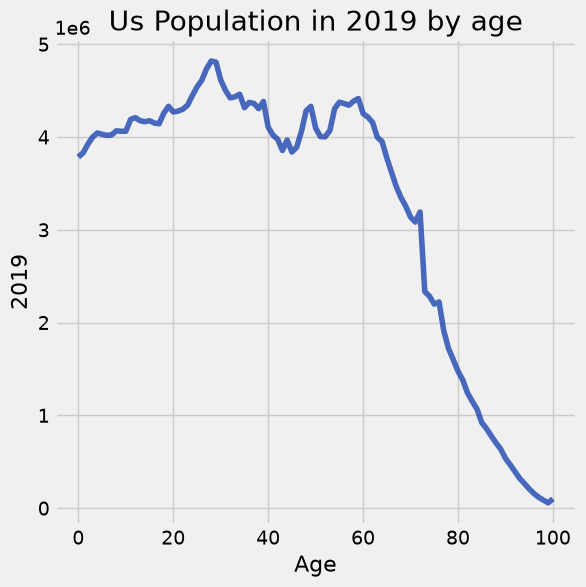

In [11]:
overall.plot('AGE', '2019')
plt.title('Us Population in 2019 by age')
plt.xlabel('Age')

In [12]:
us_pop_2019 = us_pop.drop("2014")

In [13]:
us_pop_2019

SEX,AGE,2019
0,0,3783052
0,1,3829599
0,2,3922044
0,3,3998665
0,4,4043323
0,5,4028281
0,6,4017227
0,7,4022319
0,8,4066194
0,9,4061874


**Task**: Determine the ratio of women to men among each group in the year 2019

In [14]:
females = us_pop_2019.where('SEX', 2).where('AGE', are.not_equal_to(999))

In [15]:
females

SEX,AGE,2019
2,0,1847935
2,1,1871014
2,2,1916500
2,3,1955655
2,4,1976372
2,5,1967081
2,6,1964271
2,7,1966584
2,8,1986471
2,9,1988726


In [16]:
males = us_pop_2019.where('SEX', 1).where('AGE', are.not_equal_to(999))

In [17]:
males

SEX,AGE,2019
1,0,1935117
1,1,1958585
1,2,2005544
1,3,2043010
1,4,2066951
1,5,2061200
1,6,2052956
1,7,2055735
1,8,2079723
1,9,2073148


In [18]:
sex = Table().with_columns("Age", males.column("AGE"), "Males", males.column('2019'), 'Females', females.column('2019'))
sex

Age,Males,Females
0,1935117,1847935
1,1958585,1871014
2,2005544,1916500
3,2043010,1955655
4,2066951,1976372
5,2061200,1967081
6,2052956,1964271
7,2055735,1966584
8,2079723,1986471
9,2073148,1988726


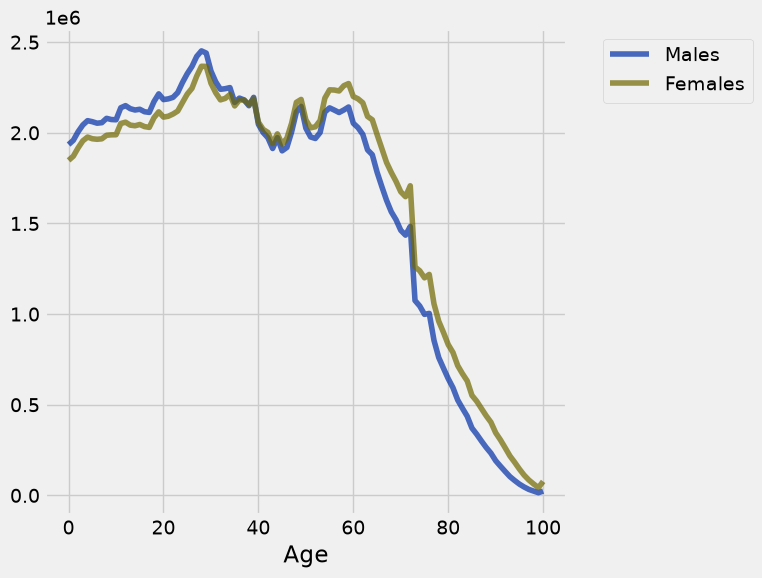

In [19]:
sex.plot('Age')

In [20]:
f_to_m_ratio = sex.column('Females') / sex.column('Males')

In [21]:
f_to_m_ratio

array([ 0.95494743,  0.95528864,  0.95560107,  0.95724201,  0.95617748,
        0.95433776,  0.95680131,  0.95663303,  0.95516134,  0.95927835,
        0.96012314,  0.95939593,  0.9575541 ,  0.95745262,  0.95915536,
        0.96056712,  0.96129319,  0.96086205,  0.95905744,  0.95524214,
        0.95575408,  0.95617502,  0.95817421,  0.95414802,  0.95151293,
        0.95156702,  0.94904573,  0.95511818,  0.96541785,  0.96988858,
        0.97123029,  0.97354917,  0.97398662,  0.97611221,  0.98294011,
        0.99106025,  0.99530339,  0.99952411,  1.00319072,  0.99612331,
        1.00585685,  1.00861853,  1.01499201,  1.01435329,  1.01068014,
        1.01942918,  1.02645551,  1.02373604,  1.02526655,  1.01785639,
        1.02262296,  1.02558422,  1.03278644,  1.03307859,  1.03631608,
        1.04649778,  1.05212404,  1.05625309,  1.06304621,  1.06042029,
        1.07176434,  1.0785374 ,  1.08748657,  1.09675723,  1.10244487,
        1.1164841 ,  1.1234195 ,  1.12821165,  1.1388741 ,  1.13

In [22]:
ratio = Table().with_columns(
    "Age", sex.column('Age'),
    'F:M Ratio', f_to_m_ratio)

In [23]:
ratio

Age,F:M Ratio
0,0.954947
1,0.955289
2,0.955601
3,0.957242
4,0.956177
5,0.954338
6,0.956801
7,0.956633
8,0.955161
9,0.959278


(0.0, 4.0)

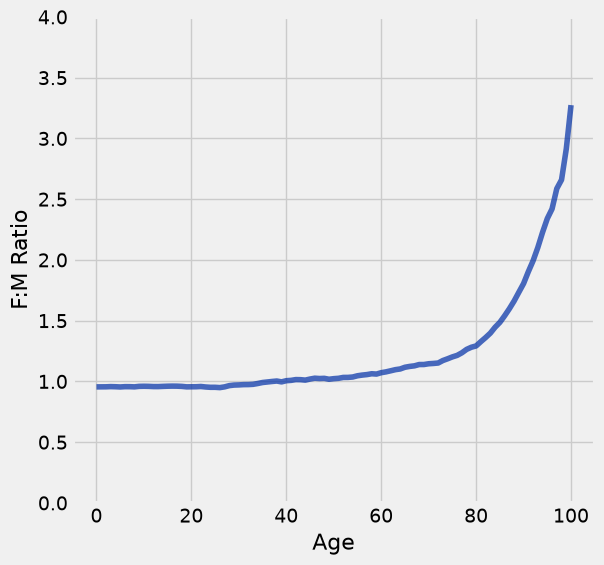

In [24]:
ratio.plot('Age')
plt.ylim(0, 4.0)

In [25]:
total_below_999 = us_pop_2019.where('AGE', are.below(999)).where('SEX', 0) 

In [26]:
total_below_999 = total_below_999.with_columns('Population (in millions)', total_below_999.column('2019')/1000000)

In [27]:
total_below_999

SEX,AGE,2019,Population (in millions)
0,0,3783052,3.78305
0,1,3829599,3.8296
0,2,3922044,3.92204
0,3,3998665,3.99866
0,4,4043323,4.04332
0,5,4028281,4.02828
0,6,4017227,4.01723
0,7,4022319,4.02232
0,8,4066194,4.06619
0,9,4061874,4.06187


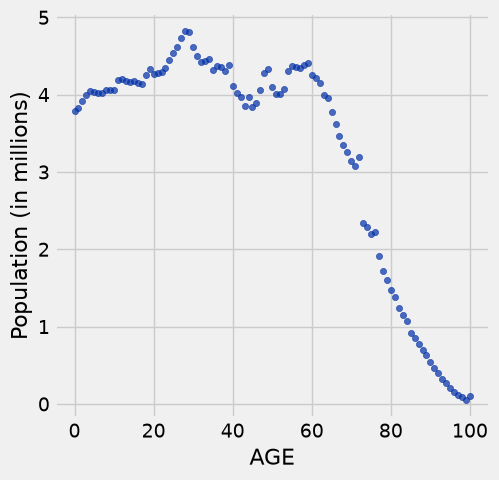

In [28]:
total_below_999.scatter('AGE', 'Population (in millions)')

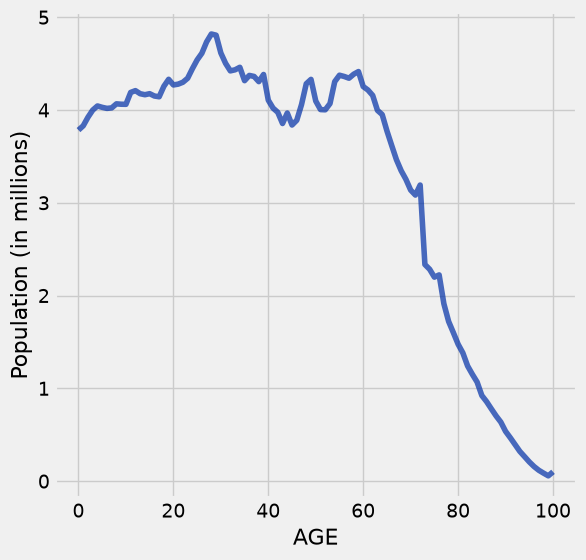

In [29]:
total_below_999.plot('AGE', 'Population (in millions)')

In [30]:
actors = Table.read_table('data/actors.csv')

In [31]:
actors

Actor,Total Gross,Number of Movies,Average per Movie,#1 Movie,Gross
Harrison Ford,4871.7,41,118.8,Star Wars: The Force Awakens,936.7
Samuel L. Jackson,4772.8,69,69.2,The Avengers,623.4
Morgan Freeman,4468.3,61,73.3,The Dark Knight,534.9
Tom Hanks,4340.8,44,98.7,Toy Story 3,415
"Robert Downey, Jr.",3947.3,53,74.5,The Avengers,623.4
Eddie Murphy,3810.4,38,100.3,Shrek 2,441.2
Tom Cruise,3587.2,36,99.6,War of the Worlds,234.3
Johnny Depp,3368.6,45,74.9,Dead Man's Chest,423.3
Michael Caine,3351.5,58,57.8,The Dark Knight,534.9
Scarlett Johansson,3341.2,37,90.3,The Avengers,623.4


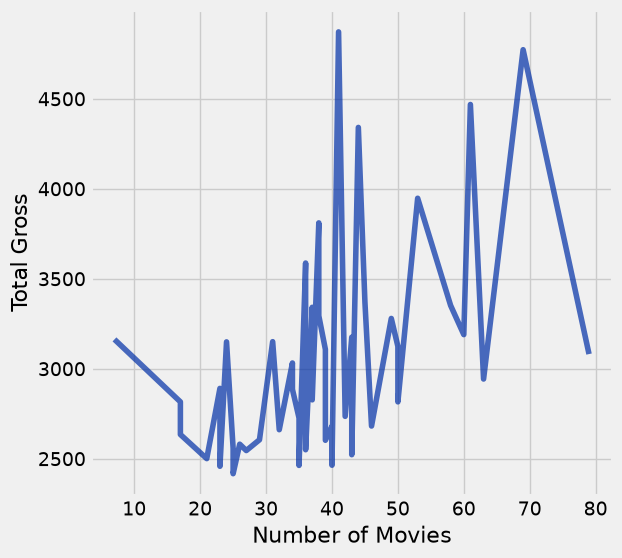

In [32]:
actors.plot('Number of Movies', 'Total Gross')

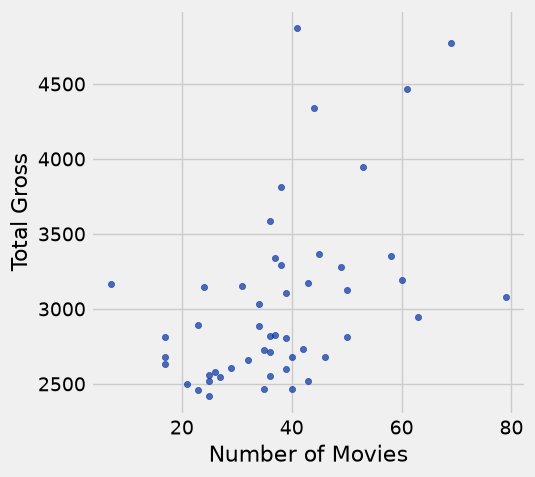

In [33]:
actors.scatter('Number of Movies', 'Total Gross')

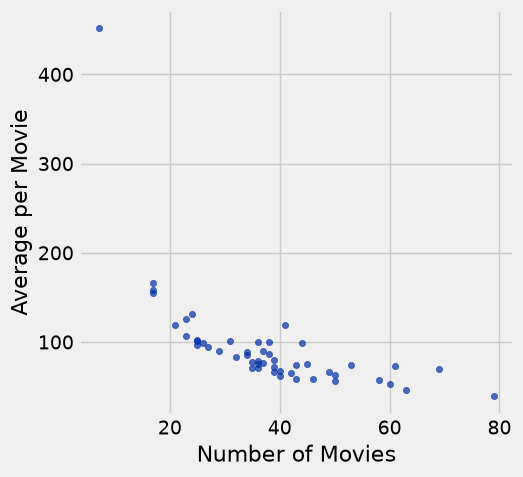

In [34]:
actors.scatter('Number of Movies', 'Average per Movie')

In [35]:
actors.where('Average per Movie', are.above(400))

Actor,Total Gross,Number of Movies,Average per Movie,#1 Movie,Gross
Anthony Daniels,3162.9,7,451.8,Star Wars: The Force Awakens,936.7


## Plots for categorical data

In [36]:
top_movies = Table.read_table('data/top_movies_2017.csv')

In [37]:
top_movies

Title,Studio,Gross,Gross (Adjusted),Year
Gone with the Wind,MGM,198676459,1796176700,1939
Star Wars,Fox,460998007,1583483200,1977
The Sound of Music,Fox,158671368,1266072700,1965
E.T.: The Extra-Terrestrial,Universal,435110554,1261085000,1982
Titanic,Paramount,658672302,1204368000,1997
The Ten Commandments,Paramount,65500000,1164590000,1956
Jaws,Universal,260000000,1138620700,1975
Doctor Zhivago,MGM,111721910,1103564200,1965
The Exorcist,Warner Brothers,232906145,983226600,1973
Snow White and the Seven Dwarves,Disney,184925486,969010000,1937


In [38]:
top_movies.sort('Gross', descending=True)

Title,Studio,Gross,Gross (Adjusted),Year
Star Wars: The Force Awakens,Buena Vista,936662225,961143200,2015
Avatar,Fox,760507625,865082100,2009
Titanic,Paramount,658672302,1204368000,1997
Jurassic World,Universal,652270625,702747400,2015
Marvel's The Avengers,Buena Vista,623357910,683474000,2012
The Dark Knight,Warner Brothers,534858444,661980500,2008
Rogue One: A Star Wars Story,Buena Vista,532177324,537326000,2016
Beauty and the Beast (2017),Buena Vista,504014165,504014165,2017
Finding Dory,Buena Vista,486295561,499245400,2016
Star Wars: Episode I - The Phantom Menace,Fox,474544677,802874300,1999


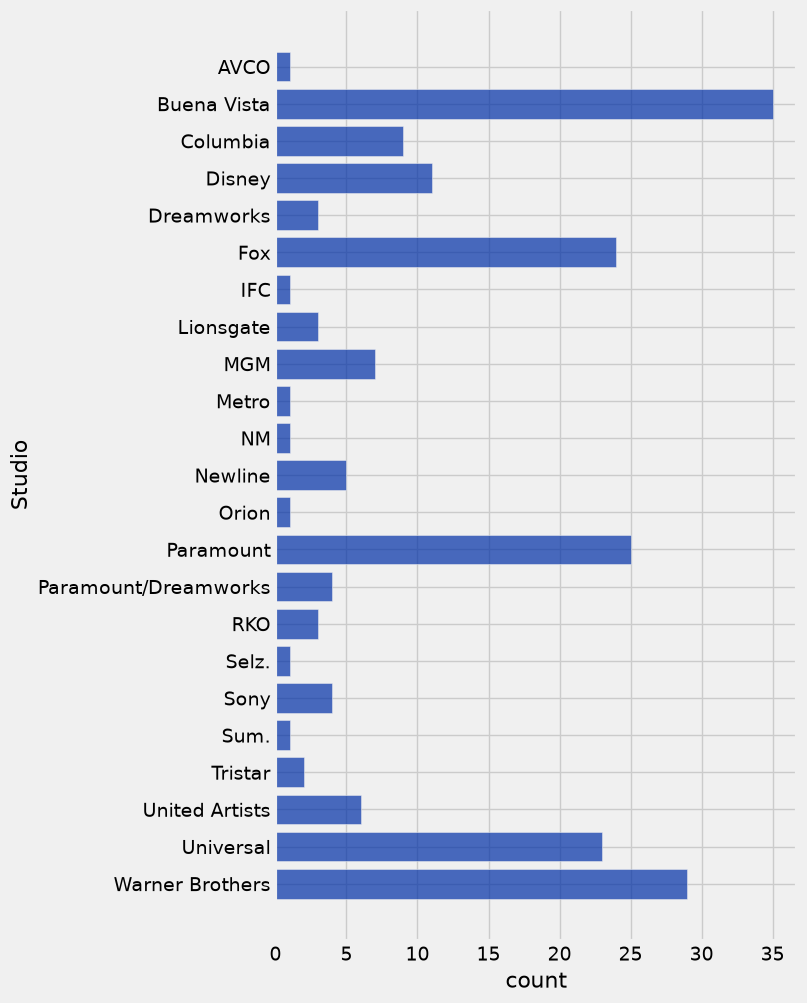

In [39]:
top_movies.group('Studio').barh('Studio', 'count')

In [76]:
top_movies = top_movies.sort('Gross', descending=True)
top_movies

Title,Studio,Gross,Gross (Adjusted),Year
Star Wars: The Force Awakens,Buena Vista,936662225,961143200,2015
Avatar,Fox,760507625,865082100,2009
Titanic,Paramount,658672302,1204368000,1997
Jurassic World,Universal,652270625,702747400,2015
Marvel's The Avengers,Buena Vista,623357910,683474000,2012
The Dark Knight,Warner Brothers,534858444,661980500,2008
Rogue One: A Star Wars Story,Buena Vista,532177324,537326000,2016
Beauty and the Beast (2017),Buena Vista,504014165,504014165,2017
Finding Dory,Buena Vista,486295561,499245400,2016
Star Wars: Episode I - The Phantom Menace,Fox,474544677,802874300,1999


In [75]:
top10_adjusted = top_movies.take(np.arange(10))
top10_adjusted

Title,Studio,Gross,Gross (Adjusted),Year
Star Wars: The Force Awakens,Buena Vista,936662225,961143200,2015
Avatar,Fox,760507625,865082100,2009
Titanic,Paramount,658672302,1204368000,1997
Jurassic World,Universal,652270625,702747400,2015
Marvel's The Avengers,Buena Vista,623357910,683474000,2012
The Dark Knight,Warner Brothers,534858444,661980500,2008
Rogue One: A Star Wars Story,Buena Vista,532177324,537326000,2016
Beauty and the Beast (2017),Buena Vista,504014165,504014165,2017
Finding Dory,Buena Vista,486295561,499245400,2016
Star Wars: Episode I - The Phantom Menace,Fox,474544677,802874300,1999


In [53]:
millions = np.round(top10_adjusted.column('Gross (Adjusted)') / 1000000, 3)
top10_adjusted = top10_adjusted.with_column('Millions', millions)
top10_adjusted

Title,Studio,Gross,Gross (Adjusted),Year,Millions
Star Wars: The Force Awakens,Buena Vista,936662225,961143200,2015,961.143
Avatar,Fox,760507625,865082100,2009,865.082
Titanic,Paramount,658672302,1204368000,1997,1204.37
Jurassic World,Universal,652270625,702747400,2015,702.747
Marvel's The Avengers,Buena Vista,623357910,683474000,2012,683.474
The Dark Knight,Warner Brothers,534858444,661980500,2008,661.98
Rogue One: A Star Wars Story,Buena Vista,532177324,537326000,2016,537.326
Beauty and the Beast (2017),Buena Vista,504014165,504014165,2017,504.014
Finding Dory,Buena Vista,486295561,499245400,2016,499.245
Star Wars: Episode I - The Phantom Menace,Fox,474544677,802874300,1999,802.874


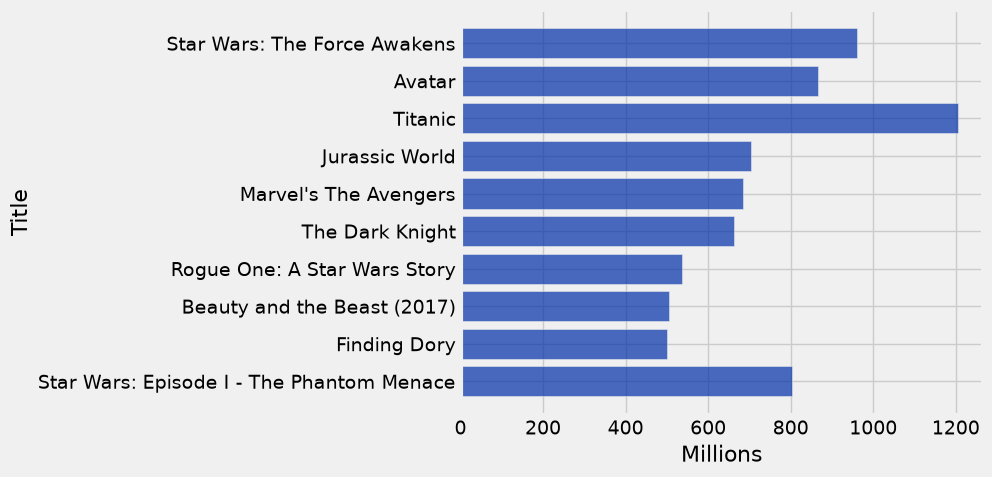

In [54]:
top10_adjusted.barh('Title', 'Millions')

**Task**: Generate a chart of age (# of years since release) for the 10 highest grossing movies

In [55]:
year = top10_adjusted.column('Year')
top10_adjusted = top10_adjusted.with_column('Age', 2026 - year)
top10_adjusted

Title,Studio,Gross,Gross (Adjusted),Year,Millions,Age
Star Wars: The Force Awakens,Buena Vista,936662225,961143200,2015,961.143,11
Avatar,Fox,760507625,865082100,2009,865.082,17
Titanic,Paramount,658672302,1204368000,1997,1204.37,29
Jurassic World,Universal,652270625,702747400,2015,702.747,11
Marvel's The Avengers,Buena Vista,623357910,683474000,2012,683.474,14
The Dark Knight,Warner Brothers,534858444,661980500,2008,661.98,18
Rogue One: A Star Wars Story,Buena Vista,532177324,537326000,2016,537.326,10
Beauty and the Beast (2017),Buena Vista,504014165,504014165,2017,504.014,9
Finding Dory,Buena Vista,486295561,499245400,2016,499.245,10
Star Wars: Episode I - The Phantom Menace,Fox,474544677,802874300,1999,802.874,27


Text(0.5, 0, 'Age')

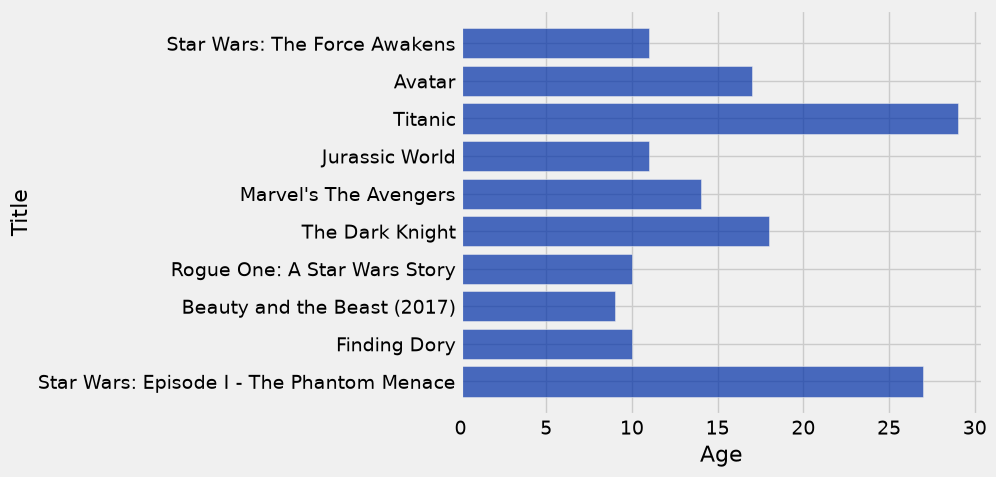

In [56]:
top10_adjusted.barh('Title', 'Age')
plt.xlabel('Age')

Text(0.5, 0, 'Age')

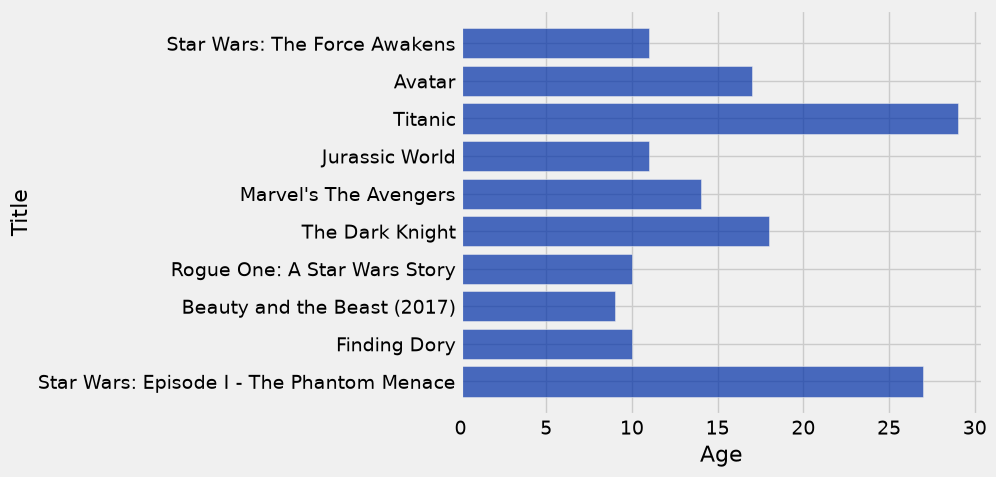

In [61]:
top10_adjusted.barh('Title', 'Age')
plt.xlabel('Age')

In [63]:
top_movies

Title,Studio,Gross,Gross (Adjusted),Year
Star Wars: The Force Awakens,Buena Vista,936662225,961143200,2015
Avatar,Fox,760507625,865082100,2009
Titanic,Paramount,658672302,1204368000,1997
Jurassic World,Universal,652270625,702747400,2015
Marvel's The Avengers,Buena Vista,623357910,683474000,2012
The Dark Knight,Warner Brothers,534858444,661980500,2008
Rogue One: A Star Wars Story,Buena Vista,532177324,537326000,2016
Beauty and the Beast (2017),Buena Vista,504014165,504014165,2017
Finding Dory,Buena Vista,486295561,499245400,2016
Star Wars: Episode I - The Phantom Menace,Fox,474544677,802874300,1999


Title,count
101 Dalmatians,1
2001: A Space Odyssey,1
9 to 5,1
Airport,1
Aladdin,1
Alice in Wonderland (2010),1
American Graffiti,1
American Sniper,1
An Officer and a Gentleman,1
Apollo 13,1


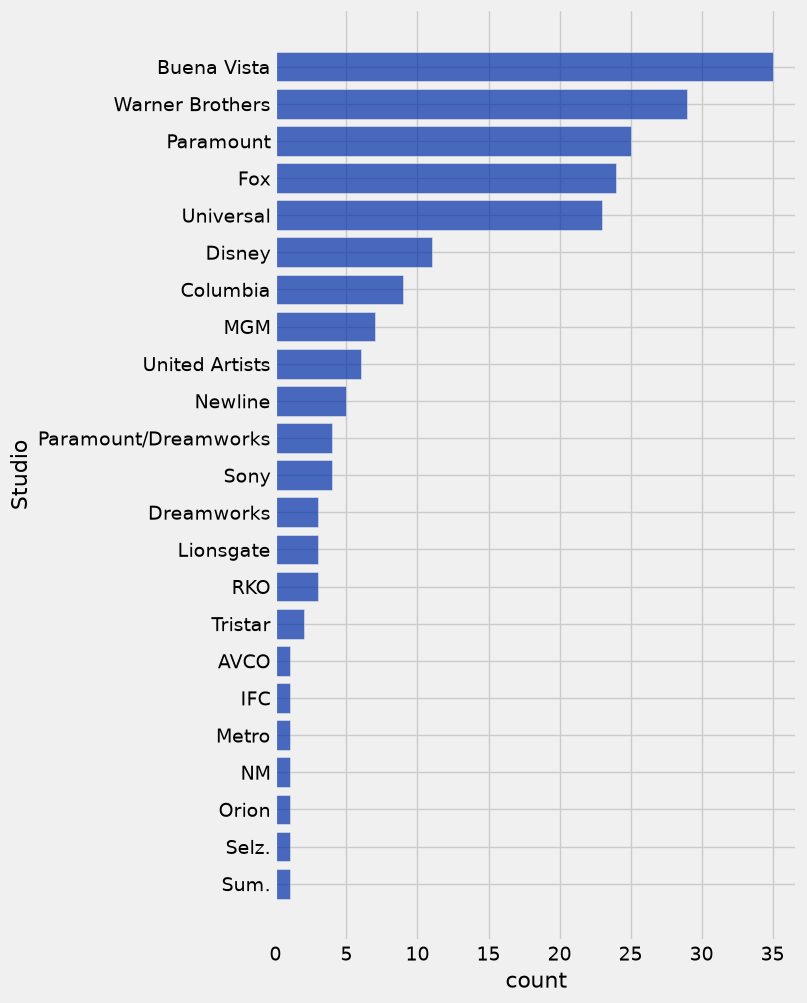

In [73]:
studio_movies = top_movies.group('Studio').sort('count', descending=True).barh('Studio')

### Use binning for numerical distributions 

In [82]:
top_movies

Title,Studio,Gross,Gross (Adjusted),Year
Star Wars: The Force Awakens,Buena Vista,936662225,961143200,2015
Avatar,Fox,760507625,865082100,2009
Titanic,Paramount,658672302,1204368000,1997
Jurassic World,Universal,652270625,702747400,2015
Marvel's The Avengers,Buena Vista,623357910,683474000,2012
The Dark Knight,Warner Brothers,534858444,661980500,2008
Rogue One: A Star Wars Story,Buena Vista,532177324,537326000,2016
Beauty and the Beast (2017),Buena Vista,504014165,504014165,2017
Finding Dory,Buena Vista,486295561,499245400,2016
Star Wars: Episode I - The Phantom Menace,Fox,474544677,802874300,1999


In [83]:
year = top_movies.column('Year')
top = top_movies.with_column('Age', 2026 - year)
top

Title,Studio,Gross,Gross (Adjusted),Year,Age
Star Wars: The Force Awakens,Buena Vista,936662225,961143200,2015,11
Avatar,Fox,760507625,865082100,2009,17
Titanic,Paramount,658672302,1204368000,1997,29
Jurassic World,Universal,652270625,702747400,2015,11
Marvel's The Avengers,Buena Vista,623357910,683474000,2012,14
The Dark Knight,Warner Brothers,534858444,661980500,2008,18
Rogue One: A Star Wars Story,Buena Vista,532177324,537326000,2016,10
Beauty and the Beast (2017),Buena Vista,504014165,504014165,2017,9
Finding Dory,Buena Vista,486295561,499245400,2016,10
Star Wars: Episode I - The Phantom Menace,Fox,474544677,802874300,1999,27


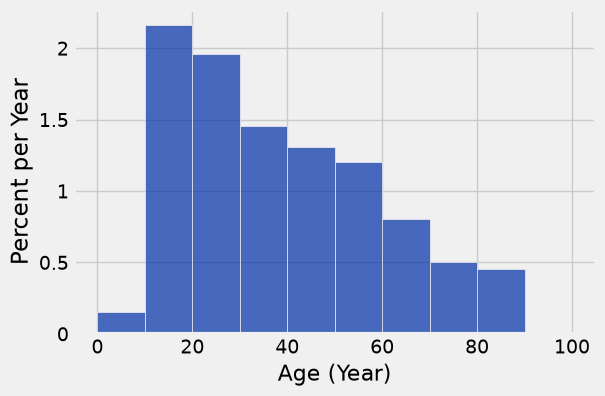

In [87]:
top.hist('Age', bins=np.arange(0, 110, 10), unit='Year')

In [90]:
my_bins = make_array(0, 5, 10, 15, 25, 40, 65, 101)

In [101]:
top

Title,Studio,Gross,Gross (Adjusted),Year,Age
Star Wars: The Force Awakens,Buena Vista,936662225,961143200,2015,11
Avatar,Fox,760507625,865082100,2009,17
Titanic,Paramount,658672302,1204368000,1997,29
Jurassic World,Universal,652270625,702747400,2015,11
Marvel's The Avengers,Buena Vista,623357910,683474000,2012,14
The Dark Knight,Warner Brothers,534858444,661980500,2008,18
Rogue One: A Star Wars Story,Buena Vista,532177324,537326000,2016,10
Beauty and the Beast (2017),Buena Vista,504014165,504014165,2017,9
Finding Dory,Buena Vista,486295561,499245400,2016,10
Star Wars: Episode I - The Phantom Menace,Fox,474544677,802874300,1999,27


In [91]:
binned_data = top.bin('Age', bins = my_bins)
binned_data

bin,Age count
0,0
5,3
10,25
15,39
25,49
40,0


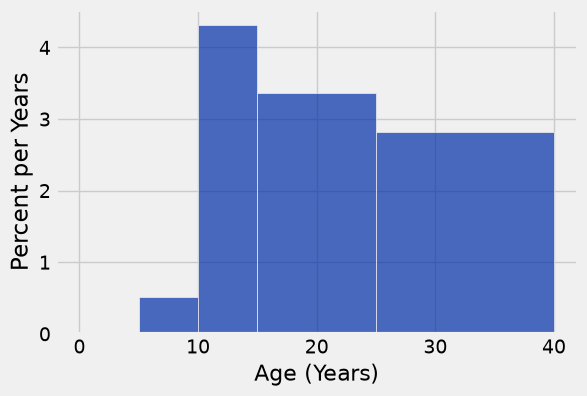

In [100]:
top.hist('Age', bins=my_bins, unit='Years')